# Project 7 — Industry-Integrated AI Synthesis

## AI Security Operations Copilot (vertical slice)

This notebook is the rubric submission for **Project 7** of the Udacity AI
Mastery Capstone. It integrates methods from three prior projects into one
agent-led SOC copilot:

- **P3 (Applied ML):** rules-first discipline + the leakage-audit lesson —
  the fusion layer is rules-only; any future ML upgrade must split by the
  independence unit (`site` + `time_window`), not shuffled rows.
- **P5 (Generative AI):** the char-level Transformer on incident-handling
  prose is the summarizer's *genre reference* (NIST SP 800-81 / CSIRT
  response style); the summarizer itself is a citation-grounded LLM call,
  not the P5 model.
- **P6 (Agentic AI):** the LangGraph governance spine
  (`src/governance/`) is lifted into P7 verbatim and a new SOC `src/domain/`
  plugs into the same `build_graph(...)`. The non-bypassable policy gate
  that hard-blocked P6's eviction/lockout becomes the human-in-the-loop gate
  for `risk_band = critical` escalation.

**Operator-centered framing.** The copilot changes the SOC analyst's job
from *triage everything* to *verify what matters*: ~1,000 raw events → a
handful of risk-scored, policy-cited incidents with a first-draft summary the
analyst edits rather than writes at 3am.

**Pipeline:**
```
surveillance_events + access_logs -> incident fusion (rules) -> risk_scored incidents
        -> RAG retrieval (Chroma, MMR, category-routed) -> LLM summary + doc_id citations
        -> LangGraph agent (fuse/score/retrieve/summarize/escalate) with a non-bypassable
           human-approval gate for critical escalations.
```

> **Reproducibility.** This notebook is tested with **Restart & Run All**.
> The deterministic pipeline (generators, fusion, RAG, stub-mode agent) runs
> without any API key. The LLM-dependent cells (summarizer, `--llm` agent)
> are guarded — they run when `GROQ_API_KEY` is set and print a clear skip
> note otherwise. `SEED = 42` governs every generator.

### 0. Environment & path bootstrap

The P7 package lives at `project_07_final_synthesis/src/`. Scripts bootstrap
the repo root onto `sys.path` and `chdir` there so the cwd-relative data
paths resolve. We replicate that here for the notebook kernel.

In [1]:
import os, sys
from pathlib import Path

# Resolve from the notebook's location (notebooks/ inside the project).
_PROJECT = Path.cwd()
# If running from notebooks/, the project root is the parent; if from
# project root, stay. Handle both.
if _PROJECT.name == "notebooks":
    _PROJECT = _PROJECT.parent
_REPO_ROOT = _PROJECT.parent
_SRC = _PROJECT / "src"
for p in (str(_PROJECT), str(_SRC), str(_REPO_ROOT)):
    if p not in sys.path:
        sys.path.insert(0, p)
os.chdir(_REPO_ROOT)
print("project:", _PROJECT.name)
print("repo root cwd:", Path.cwd())
print("python:", sys.version.split()[0])

project: project_07_final_synthesis
repo root cwd: D:\AI_Master\Udacity\capstone_projects
python: 3.12.3


### 1. Deterministic synthetic data generation

One site, one zone, ~10 devices, ~20 users, ~50 surveillance events
(exactly 3 anomalies), ~200 access logs (exactly 1 tailgate, 4-row denial
burst). Every generator uses `SEED = 42`; anomaly/tailgate counts are fixed
(deterministic, not Bernoulli rates) so the fusion rules fire predictably
every run.

In [2]:
from src.generators.run_all import main as gen_all
gen_all()

ref: data\reference\sites.csv
ref: data\reference\zones.csv
ref: data\reference\devices.csv
ref: data\reference\users.csv
---
wrote project_07_final_synthesis\data\synthetic\surveillance_events.parquet  rows=50 anomalies=3 (6.0%)
events: project_07_final_synthesis\data\synthetic\surveillance_events.parquet
wrote project_07_final_synthesis\data\synthetic\access_logs.parquet  rows=200 denied=18 tailgate=1
logs:   project_07_final_synthesis\data\synthetic\access_logs.parquet


### 2. Incident fusion (rules-first)

Four detectors — `intrusion_restricted`, `repeated_denials`,
`cross_anomaly`, `tailgate_door` — run over the events + logs and emit
risk-scored incidents. Risk = per-rule base + size bonus + confidence
bonus, capped at 100. The `risk_band` threshold (critical ≥ 75 / 80) is
the human-review gate. The originating rule is kept on each incident row
(`_rule`) for the post-incident audit trail.

> **P3 discipline.** Rules are the first layer; ML is a later upgrade
> (skipped in this slice). Any ML scorer must be evaluated on a split that
> respects the independence unit (`site` + contiguous `time_window`), never
> shuffled rows — the P3 smoke-detection audit showed a 0.9998 random-split
> F1 that collapsed to ~0 sensitivity under Leave-One-Session-Out CV.

In [3]:
from src.fusion.incidents import main as fuse
fuse()

wrote project_07_final_synthesis\data\synthetic\incidents.parquet  rows=4 by_band={'high': 3, 'critical': 1} critical=1


WindowsPath('project_07_final_synthesis/data/synthetic/incidents.parquet')

In [4]:
import pandas as pd
incidents = pd.read_parquet("project_07_final_synthesis/data/synthetic/incidents.parquet")
incidents[["incident_id","incident_type","risk_score","risk_band","_rule",
           "linked_event_ids","linked_log_ids","human_review_required"]]

,incident_id,incident_type,risk_score,risk_band,_rule,linked_event_ids,linked_log_ids,human_review_required
0,INC-000001,suspected_unauthorized_entry,82,critical,intrusion_restricted,EVT-000038,,True
1,INC-000002,repeated_badge_denials,64,high,repeated_denials,,"LOG-000055,LOG-000061,LOG-000062",False
2,INC-000003,cross_anomaly_correlation,75,high,cross_anomaly,EVT-000038,LOG-000022,False
3,INC-000004,tailgate_door_activity,68,high,tailgate_door,,LOG-000084,False


### 3. RAG layer — knowledge base + MMR retriever

Five hand-written policy docs (KB-00001..KB-00005) embedded with
`sentence-transformers` `all-MiniLM-L6-v2` (384-dim) into a persistent
Chroma collection. Retrieval is **MMR** (k=3, λ=0.5) with **category
routing**: the fusion layer already knows the incident type, so
`retrieve_for_incident` boosts the matching KB category by +0.3 before
MMR. This fixes a real mis-ranking — pure cosine ranked the tailgate and
privacy policy docs 2nd/3rd for their own topic because all five docs
share policy vocabulary (badge, human review, retention).

> **Native chromadb + sentence-transformers, no LangChain wrappers** — the
> `langchain_chroma`/`langchain_huggingface` packages aren't installed and
> would add a layer for nothing on a 5-doc KB. MMR is ~15 lines inline.

In [5]:
from src.rag.knowledge_base_loader import build_vector_store
n, store = build_vector_store()
print(f"KB vector store: {n} docs at {store}")

D:\AI_Master\Udacity\capstone_projects\project_07_final_synthesis\final_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6353.14it/s]

KB vector store: 5 docs at project_07_final_synthesis\data\knowledge_base\vector_store


In [6]:
from src.rag.retriever import retrieve_for_incident

# Route each fused incident_type to its policy; assert the matching doc ranks #1.
for _, r in incidents.iterrows():
    docs = retrieve_for_incident(r["incident_type"], r["incident_type"], k=1)
    top = docs[0] if docs else None
    print(f"{r['incident_id']} [{r['risk_band']}] {r['incident_type']:30s} -> "
          f"{top['doc_id']} ({top['category']}) score={top['score']:.3f}"
          if top else f"{r['incident_id']} -> MISS")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5166.20it/s]

INC-000001 [critical] suspected_unauthorized_entry   -> KB-00001 (intrusion) score=0.402



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5717.26it/s]

...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5517.76it/s]

INC-000003 [high] cross_anomaly_correlation      -> KB-00003 (correlation) score=0.183



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5671.10it/s]

INC-000004 [high] tailgate_door_activity         -> KB-00005 (privacy) score=0.769


### 4. RAG self-check

`scripts/check_rag.py` asserts that every fused incident type routes to
its matching policy document at rank 1, with diverse neighbors at k=3.

In [7]:
import subprocess, sys
r = subprocess.run([sys.executable, str(_PROJECT/"scripts"/"check_rag.py"), "--k","3"],
                   capture_output=True, text=True)
print(r.stdout)
if r.returncode != 0:
    print("STDERR:", r.stderr); raise SystemExit("RAG self-check failed")

OK suspected_unauthorized_entry   -> KB-00001 (intrusion) score=0.656
    neighbor  KB-00002 (denials) score=0.482
    neighbor  KB-00003 (correlation) score=0.428
OK repeated_badge_denials         -> KB-00002 (denials) score=0.592
    neighbor  KB-00001 (intrusion) score=0.773
    neighbor  KB-00003 (correlation) score=0.421
OK cross_anomaly_correlation      -> KB-00003 (correlation) score=0.409
    neighbor  KB-00002 (denials) score=0.496
    neighbor  KB-00001 (intrusion) score=0.574
OK tailgate_door_activity         -> KB-00004 (tailgate) score=0.449
    neighbor  KB-00002 (denials) score=0.681
    neighbor  KB-00001 (intrusion) score=0.488
ALL CORRECT



### 5. LLM summarizer (Groq, citation-guarded)

The summarizer fills `summary_text` / `recommended_action` /
`citation_doc_ids` on each incident, grounded in the retrieved policy docs.
Provider is **Groq Cloud `llama-3.1-8b-instant`** (free tier) via `requests`
(no `openai` SDK). The **citation guard** (validate + one retry) parses
`KB-XXXXX` ids from the model output, drops any not in the retrieved set,
re-prompts once if zero survive, and falls back to `needs_review` otherwise
— enforcing the rule *hallucinated policies are bugs* on a smaller free
model.

> **Guarded cell.** Runs only if `GROQ_API_KEY` is set (loaded from
> `.env`). Without a key, the pipeline above is still complete; the
> summaries from a prior run may already be on the incidents parquet.

In [8]:
from dotenv import load_dotenv
load_dotenv(_PROJECT / ".env")
HAS_GROQ = bool(os.environ.get("GROQ_API_KEY"))
print("GROQ_API_KEY set:", HAS_GROQ)

GROQ_API_KEY set: True


In [9]:
if HAS_GROQ:
    from src.agent.summarizer import main as summarize
    summarize()
else:
    print("[skip] GROQ_API_KEY not set — summarizer cell skipped.\n"
          "Set it in project_07_final_synthesis/.env (free key: console.groq.com/keys) "
          "to run the live LLM summaries.")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5223.36it/s]

INC-000001 [ok] risk=critical 
summary: A suspected unauthorized entry has occurred in ZONE-001 with a risk score of 82. The incident is cri cites=KB-00001



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6105.76it/s]

...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5303.64it/s]

INC-000003 [ok] risk=high 
summary: A high-risk incident (risk_score=75) has been detected in ZONE-001 due to a cross-anomaly correlatio cites=KB-00003



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4410.14it/s]

INC-000004 [ok] risk=high 
summary: A high-risk tailgate_door_activity incident (risk_score=68) occurred in ZONE-001, indicating a possi cites=KB-00004
wrote incidents with summaries: 4 ok, 0 needs_review


In [10]:
# Show whatever summaries are on the incidents parquet (from this run or a prior one).
import pandas as pd
inc = pd.read_parquet("project_07_final_synthesis/data/synthetic/incidents.parquet")
cols = ["incident_id","risk_band","citation_doc_ids","summary_text","recommended_action"]
view = inc[cols].copy()
view["summary_text"] = view["summary_text"].str.slice(0, 90)
view["recommended_action"] = view["recommended_action"].str.slice(0, 60)
view

,incident_id,risk_band,citation_doc_ids,summary_text,recommended_action
0,INC-000001,critical,KB-00001,A suspected unauthorized entry has occurred in...,Dispatch on-site security to ZONE-001 within 5...
1,INC-000002,high,KB-00002,A high-risk badge denial incident (INC-000002)...,Suspend the badge pending identity verificatio...
2,INC-000003,high,KB-00003,A high-risk incident (risk_score=75) has been ...,Dispatch on-site security to the affected zone...
3,INC-000004,high,KB-00004,A high-risk tailgate_door_activity incident (r...,Dispatch security to the scene and hold the do...


### 6. LangGraph agent + 5 tools (the synthesis)

The governance spine (lifted from P6) compiles P7's SOC agent unchanged via
`build_graph(policy, tool_registry, tool_specs, audit, llm, memory,
intake_fn, prompts)`. The graph topology:

```
START -> ingest -> planner -> worker -> reviewer
reviewer -> {allow: worker_dispatch, require_human: human_approval, block: summarizer}
worker_dispatch -> {more steps: worker, done: summarizer}   # the plan loop
human_approval -> worker_dispatch
summarizer -> END
```

The worker **never** calls a tool directly — the reviewer gate is the only
path to `worker_dispatch`. The reviewer is a pure predicate evaluator (no
LLM), so it cannot be talked into approving. `incident.escalate` requires
`risk_band_score ≥ 75` AND a human; `case.close` is hard-blocked (the agent
never auto-closes — the analyst is the closer).

**One fix to the donated spine:** the plan-loop edge was
`dispatch -> reviewer`, which meant the worker (which loads the next plan
step into `current_action`) only ran once, so step 0's action re-ran N times.
P6's single-step scenarios never hit it; P7's multi-step triage plan did.
Fixed to `dispatch -> worker`. See `src/governance/graph_builder.py`.

In [11]:
from src.agent.copilot_agent import build_system
sys_stub = build_system(use_llm=False)
print("graph built (stub mode). nodes:", list(sys_stub.graph.nodes))

graph built (stub mode). nodes: ['__start__', 'ingest', 'planner', 'worker', 'reviewer', 'worker_dispatch', 'summarizer', 'human_approval']


graph diagram written to d:\AI_Master\Udacity\capstone_projects\project_07_final_synthesis\reports\agent_graph.png


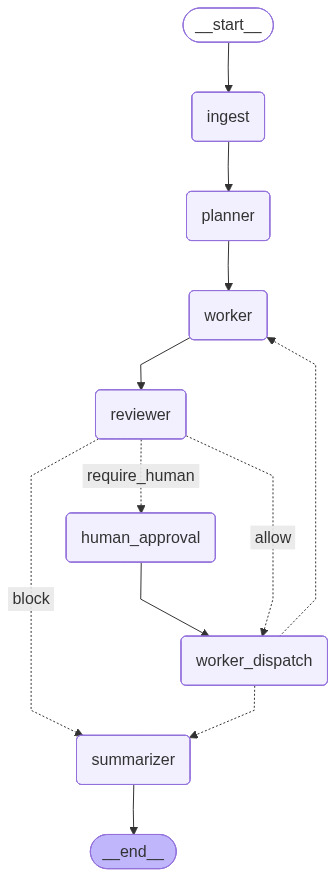

In [23]:
from IPython.display import Image, display
from src.agent.copilot_agent import build_system

# Render the compiled graph to reports/agent_graph.png and show it inline.
graph_img = build_system(use_llm=False).graph.get_graph().draw_mermaid_png()
# reports/ lives at the project root (sibling of src/, notebooks/, etc.).
REPORTS_DIR = _PROJECT / "reports"
graph_path = REPORTS_DIR / "agent_graph.png"
graph_path.parent.mkdir(exist_ok=True)
graph_path.write_bytes(graph_img)
print('graph diagram written to', graph_path)
display(Image(filename=str(graph_path)))

### 7. Stub-mode agent run (deterministic, no LLM)

Runs the copilot on the critical incident `INC-000001` with a scripted plan
(`fuse -> score -> retrieve -> summarize -> escalate`). The critical-band
escalation routes through `human_approval` (auto-approved in demo mode).
The audit trail shows every tool call + reviewer verdict.

In [12]:
# Start a fresh audit trail for a readable per-run view. audit.jsonl is
# append-only by design; scratchpad.db may be held open by a prior run's
# SQLite handle, so tolerate the unlink instead of crashing.
(_PROJECT / "data" / "audit.jsonl").unlink(missing_ok=True)
try:
    (_PROJECT / "data" / "scratchpad.db").unlink(missing_ok=True)
except PermissionError:
    pass  # held open by a prior run in this kernel — fine, it'll be reused

from src.agent.copilot_agent import run_incident
state = run_incident("INC-000001", use_llm=False)
print("status:", state.get("status"))
tr = state.get("tool_result")
if tr:
    print(f"last tool: {tr.tool} ok={tr.ok}")
    print(f"  summary: {tr.summary}")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6387.99it/s]


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5779.06it/s]

status: done
last tool: incident.escalate ok=True
  summary: {'incident_id': 'INC-000001', 'risk_band_score': 82, 'risk_band': 'critical', 'escalated': True, 'action': 'page_duty_manager', 'note': 'Escalation recorded; awaiting human approval (demo auto-approves).'}


In [13]:
import json
rows = [json.loads(l) for l in open(_PROJECT/"data"/"audit.jsonl") if l.strip()]
print(f"audit rows: {len(rows)}")
for r in rows:
    kind = r.get("kind","?")
    if kind == "call":
        print(f"  CALL  {r['action']}")
    elif kind == "block":
        print(f"  BLOCK {r.get('action')} :: {r.get('block_reason','')[:50]}")
    elif r.get("node") == "reviewer" and r.get("decision") != "allow":
        print(f"  REVIEW {r.get('decision')}")
    elif r.get("node") == "human_approval":
        print(f"  HUMAN-APPROVAL (gate for critical escalation)")

audit rows: 14
  CALL  incident.fuse
  CALL  incident.score
  CALL  sop.retrieve
  CALL  incident.summarize
  HUMAN-APPROVAL (gate for critical escalation)
  CALL  incident.escalate


### 8. LLM-planned agent run (live, Groq)

With `--llm`, the planner generates the plan from the staged incident text
via Groq instead of using the scripted plan. The plan loop, reviewer gate,
and human-approval gate all run for real. **This is the live-agent
demonstration; the stub-mode run above is the reproducible one.**

In [14]:
if HAS_GROQ:
    # Fresh audit log for the LLM run (scratchpad.db may be held open by the
    # prior stub run's SQLite handle -> tolerate the unlink).
    (_PROJECT / "data" / "audit.jsonl").unlink(missing_ok=True)
    try:
        (_PROJECT / "data" / "scratchpad.db").unlink(missing_ok=True)
    except PermissionError:
        pass
    state_llm = run_incident("INC-000001", use_llm=True)
    print("status:", state_llm.get("status"))
    tr = state_llm.get("tool_result")
    if tr:
        print(f"last tool: {tr.tool} ok={tr.ok}")
        print(f"  summary: {str(tr.summary)[:80]}")
else:
    print("[skip] GROQ_API_KEY not set — LLM-planned agent run skipped.\n"
          "Run `final_venv\\Scripts\\python.exe src\\agent\\copilot_agent.py "
          "--incident INC-000001 --llm` with a key to see the live planner.")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5400.23it/s]


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5596.75it/s]

status: done
last tool: incident.escalate ok=True
  summary: {'incident_id': 'INC-000001', 'risk_band_score': 90, 'risk_band': 'critical', 'e


### 9. Test suite

The full suite — carryover governance-agnosticism + policy-predicate tests
(both domains flow through the same constraint evaluator) and P7's
`test_escalate_blocked` (high-band escalate blocked; critical-band escalate
requires human) — must be green.

In [15]:
r = subprocess.run([sys.executable, "-m", "pytest", str(_PROJECT/"tests"), "-q"],
                   capture_output=True, text=True)
print(r.stdout[-400:])
if r.returncode != 0:
    print("STDERR:", r.stderr[-400:]); raise SystemExit("tests failed")

...............                                                          [100%]
15 passed in 17.32s



### 10. Reflection

**What this slice proves.** Three prior projects genuinely integrate into
one system, not a collage: P3's rules-first discipline is the fusion layer's
design (and the leakage-audit lesson gates any future ML); P5's genre choice
grounds the summarizer's prose style; P6's governance spine is reused
verbatim, with the non-bypassable policy gate re-purposed as the SOC
human-in-the-loop for critical escalations. The same constraint mechanism
that enforced P6's spend cap enforces P7's risk-band gate — asserted in
`test_policy_predicate.py`.

**Honest limitations.**
- **Scale:** 1 site, 1 zone, ~50 events / ~200 logs / 4 incidents — enough
  to demonstrate the pipeline and the governance guarantees, not enough to
  train a real ML scorer.
- **RAG ranking:** pure cosine mis-ranks the tailgate/privacy docs because
  the KB shares vocabulary; the fix is category *routing* on the known
  incident type, not a bigger embedding model.
- **Free model:** Groq `llama-3.1-8b-instant` is fast and free but a smaller
  model; the citation guard is what makes "hallucinated policies are bugs"
  enforceable on it.
- **One spine fix:** the multi-step plan-loop bug was latent in the donor
  (P6's scenarios were all single-step); documented in `graph_builder.py`.

**What I'd do with more time.** Per-site ML calibration (P3's transferable
pattern) on a larger synthetic corpus; a `--checkpointer` for multi-session
resume; a real human-in-the-loop UI on the `human_approval` node instead of
demo auto-approval; and scaling the KB + corpus to evaluate citation
faithfulness quantitatively, not just by guard-pass.